In [1]:
%%bash
pip install rasterio
pip install scikit-image

wget -nc -q https://nimbus.niu.edu/courses/EAE483/rgb_imagery.tif

# L9 - Image Thresholding

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand scikit-image and its basic methods. We will walk through some examples of how scikit-image can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

### scikit-image

This package, sometimes called ["skimage"](https://scikit-image.org/), provides an interface to many methods for digital image processing. We will work with both RGB (3, y, x) and grayscale images (y, x).

### Problem 1

We will be looking at an aerial image over a mountain range. This image is an RGB image in the format (channels, y, x).

Recall last time that we examined how modifying each channel changed the general color of the image. Turning up/down some channels either highlighted or diminished certain features.

Try the same again with the image used for this lab to see how these tweaks modify the picture:

(np.float64(-0.5), np.float64(1279.5), np.float64(1023.5), np.float64(-0.5))

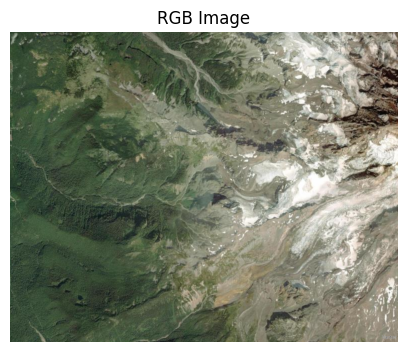

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = "rgb_imagery.tif"

with rasterio.open(tif_path) as src:
    arr = src.read()

rgb = np.transpose(arr[:3], (1, 2, 0))
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title(f"RGB Image")
plt.axis("off")

**Problem 1a**

Use what we learned about RGB images to set `green` equal to the 3-channel representation of green.

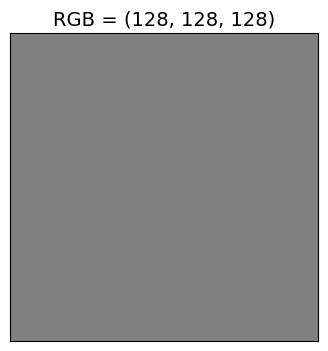

In [3]:
green = (128, 128, 128)

pixel = np.array([[[green[0], green[1], green[2]]]], dtype=np.uint8)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(pixel, interpolation='nearest')
ax.set_title(f"RGB = ({green[0]}, {green[1]}, {green[2]})", fontsize=14)
ax.set_xticks([]);
ax.set_yticks([]);

**Problem 1b**

We will be performing multichannel [image thresholding](https://en.wikipedia.org/wiki/Thresholding_(image_processing)). We are applying a simple conditional test to each channel to identify pixels of interest (white / True) against the "background" (black / False). In this case, we wanted to identify "greenish" pixels.

`numpy.ndarray` can be manipulated much like pandas DataFrames are filtered.

For example:

```
green = df[df['color']=='green']
```

Would give us all rows where the column value was 'green'

In numpy, we can use indexing shortcuts to identify pixels of interest.

Assume that we create a simple `int` array named `example` that has the values `1`, `3`, `5` and `10`.

In [4]:
example = np.array([[10, 5, 1, 5],
                   [5, 1, 5, 10],
                   [3, 5, 3, 5],
                   [10, 10, 1, 10]])

We could use a simple conditional equivalence test to identify pixels that are equal to `5` and those that are not. Recall that `True` and `False` are a special type of `int` that can only be `1` (`True`) or `0` (`False`). This is useful to remember later when we use the result of conditional tests to [mask images](https://en.wikipedia.org/wiki/Mask_(computing)#Image_masks).

In [5]:
eq_to_5 = example == 5

print(eq_to_5)

[[False  True False  True]
 [ True False  True False]
 [False  True False  True]
 [False False False False]]


We can plot the original data and the "mask" to show what pixels passed the test and what pixels did not pass the test. You will notice that all pixels with a value of 5 on the left are white (True) on the right, and all pixels that are not 5 are black (False) on the right.

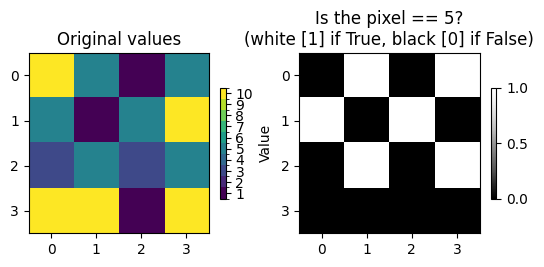

In [6]:
import matplotlib.colors as mcolors

cmap = plt.get_cmap('viridis', 10)
bounds = np.arange(0.5, 10.6, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(example, cmap=cmap, norm=norm)
ax.set_title("Original values")

cbar = plt.colorbar(mmp, ax=ax, shrink=0.3, ticks=np.arange(1, 11))
cbar.set_label("Value")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(eq_to_5, cmap='Greys_r')
ax.set_title("Is the pixel == 5?\n(white [1] if True, black [0] if False)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

plt.show()



---


**Change the code below so that the right side is white (`True`) if the pixel is 1 or 5**



---



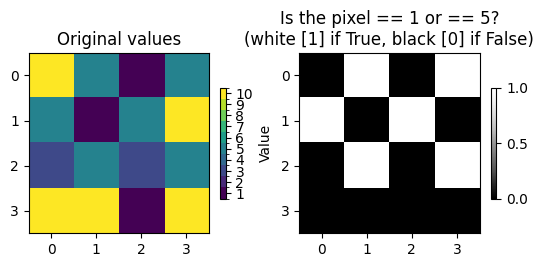

In [7]:
import matplotlib.colors as mcolors

cmap = plt.get_cmap('viridis', 10)
bounds = np.arange(0.5, 10.6, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(example, cmap=cmap, norm=norm)
ax.set_title("Original values")

cbar = plt.colorbar(mmp, ax=ax, shrink=0.3, ticks=np.arange(1, 11))
cbar.set_label("Value")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(eq_to_5, cmap='Greys_r')
ax.set_title("Is the pixel == 1 or == 5?\n(white [1] if True, black [0] if False)")
plt.colorbar(mmp, ax=ax, shrink=0.3)

plt.show()

We can use the same approach for identifying pixels of interest in RGB images:

1. Put each channel into its own array
2. Apply a test for each array
3. For every pixel that is `True`, the tests passed for each channel, suggesting equivalence.

In the example above, we modified `green` to be equivalent to the 3 channel representation of the color green.

We can follow the steps above to identify where the image is "green"

1. Put each channel into its own array

Recall that `rgb` to work with matplotlib is (y, x, channel).



---


**Problem 1b.1**

Fix the following code to set the `r`, `g`, and `b` variables correctly.



---



In [8]:
r = rgb[:, :, 0]
g = rgb[:, :, 0]
b = rgb[:, :, 0]

2. Apply a test for each array

We want to see if it is "green", so each channel must ``==`` the value in each `green` channel. We combine these tests using the `&` operator. In other words, all tests must be true for that pixel to be shown as equivalent to the selected color:



---



**Problem 1b.2**

Fix the following conditions to match the `r`, `g`, and `b` channels you defined earlier**



---



In [9]:
cond = (r == green[0]) & (g == green[0]) & (b == green[0])

`cond` is now a "grayscale" image of size (y, x) instead of (y, x, 3)

Finally, we can plot the results next to the original image:

Text(0.5, 1.0, "color matched with 'green'\n(white = True, black = False)")

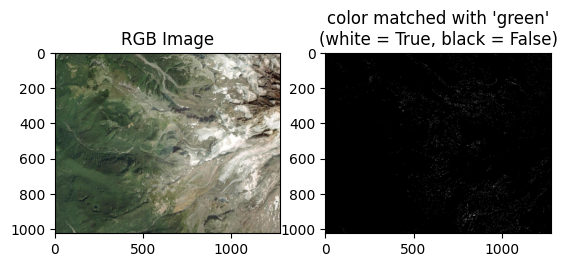

In [10]:
ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(cond, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title("color matched with 'green'\n(white = True, black = False)")

That's weird! I see a lot of green in the image, but no (or very few, depending on your choices for green) pixels actually show up as matching green!

We can examine the values more closely by zooming into an area in the image to see if we missed something.

The following code shows a subregion defined by ystart, yend, xstart, xend

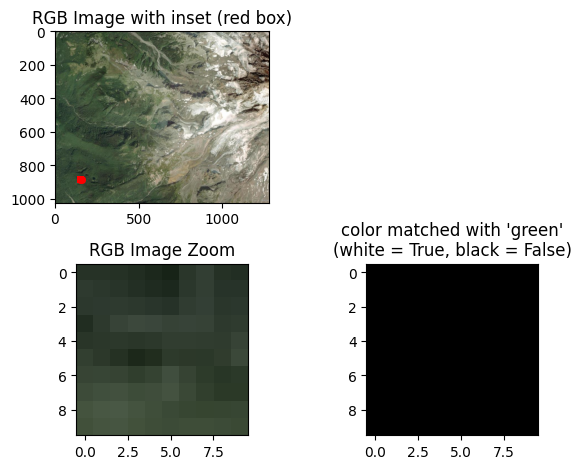

In [11]:
xstart = 150
xend = 160
ystart = 880
yend = 890

rgb_subset = rgb[ystart:yend, xstart:xend, :]
cond_subset = cond[ystart:yend, xstart:xend]

ax = plt.subplot(2, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image with inset (red box)")
ax.plot([xstart, xstart, xend, xend, xstart],
         [ystart, yend, yend, ystart, ystart],
         "r-", lw=5)

ax = plt.subplot(2, 2, 3)
mmp = ax.imshow(rgb_subset)
ax.set_title("RGB Image Zoom")

ax = plt.subplot(2, 2, 4)
mmp = ax.imshow(cond_subset, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title("color matched with 'green'\n(white = True, black = False)")

plt.tight_layout()

What values are associated with the subset? It looks green to me!

*click "show data" if prompted*

In [12]:
rgb_subset

array([[[38, 50, 38],
        [38, 50, 38],
        [37, 49, 37],
        [33, 45, 33],
        [28, 40, 28],
        [23, 35, 23],
        [42, 54, 42],
        [50, 62, 51],
        [37, 49, 37],
        [34, 46, 35]],

       [[46, 58, 47],
        [43, 55, 44],
        [40, 52, 41],
        [35, 47, 36],
        [31, 43, 32],
        [28, 40, 29],
        [43, 55, 44],
        [50, 62, 51],
        [39, 51, 41],
        [39, 51, 41]],

       [[44, 56, 45],
        [45, 57, 47],
        [46, 58, 47],
        [44, 56, 45],
        [41, 53, 43],
        [38, 50, 40],
        [48, 60, 49],
        [51, 63, 53],
        [42, 54, 43],
        [43, 55, 45]],

       [[33, 45, 33],
        [45, 57, 45],
        [55, 67, 55],
        [60, 72, 60],
        [58, 70, 59],
        [54, 66, 54],
        [55, 67, 56],
        [54, 66, 54],
        [45, 57, 45],
        [47, 59, 47]],

       [[41, 53, 40],
        [43, 55, 42],
        [44, 56, 43],
        [42, 54, 41],
        [44, 56, 43],
        [49, 61, 48],
        [49, 61, 48],
        [48, 60, 47],
        [47, 59, 46],
        [55, 67, 54]],

       [[50, 63, 48],
        [44, 56, 42],
        [37, 49, 35],
        [28, 40, 26],
        [33, 45, 30],
        [45, 58, 43],
        [44, 56, 41],
        [43, 56, 41],
        [48, 60, 45],
        [59, 72, 57]],

       [[55, 68, 52],
        [55, 69, 53],
        [54, 67, 51],
        [48, 62, 45],
        [53, 67, 50],
        [64, 78, 62],
        [54, 67, 51],
        [45, 59, 42],
        [40, 54, 38],
        [43, 57, 41]],

       [[61, 75, 57],
        [64, 79, 61],
        [66, 80, 62],
        [61, 76, 57],
        [63, 77, 59],
        [68, 82, 64],
        [58, 72, 54],
        [49, 63, 45],
        [43, 57, 39],
        [43, 57, 39]],

       [[68, 83, 62],
        [72, 87, 67],
        [73, 88, 69],
        [68, 83, 63],
        [63, 78, 58],
        [58, 73, 54],
        [55, 70, 50],
        [54, 69, 48],
        [54, 69, 49],
        [55, 70, 51]],

       [[65, 80, 58],
        [69, 84, 63],
        [70, 85, 65],
        [66, 81, 59],
        [62, 77, 56],
        [60, 75, 55],
        [62, 77, 56],
        [62, 77, 56],
        [60, 75, 55],
        [58, 73, 52]]], dtype=uint8)



---


**Problem 1b.3**

Modify the code below to zoom in on a different, but green, subregion far away from the original subregion.



---



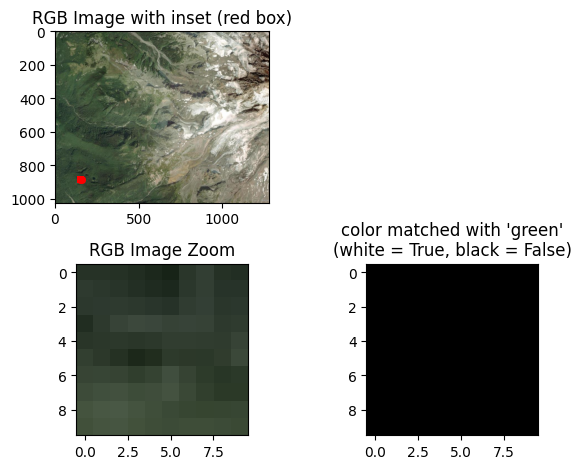

In [13]:
xstart = 150
xend = 160
ystart = 880
yend = 890

rgb_subset = rgb[ystart:yend, xstart:xend, :]
cond_subset = cond[ystart:yend, xstart:xend]

ax = plt.subplot(2, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image with inset (red box)")
ax.plot([xstart, xstart, xend, xend, xstart],
         [ystart, yend, yend, ystart, ystart],
         "r-", lw=5)

ax = plt.subplot(2, 2, 3)
mmp = ax.imshow(rgb_subset)
ax.set_title("RGB Image Zoom")

ax = plt.subplot(2, 2, 4)
mmp = ax.imshow(cond_subset, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title("color matched with 'green'\n(white = True, black = False)")

plt.tight_layout()

Examine your new subset to see what values are in this region for each channel.

*Click "Show data" if prompted"

In [14]:
rgb_subset

array([[[38, 50, 38],
        [38, 50, 38],
        [37, 49, 37],
        [33, 45, 33],
        [28, 40, 28],
        [23, 35, 23],
        [42, 54, 42],
        [50, 62, 51],
        [37, 49, 37],
        [34, 46, 35]],

       [[46, 58, 47],
        [43, 55, 44],
        [40, 52, 41],
        [35, 47, 36],
        [31, 43, 32],
        [28, 40, 29],
        [43, 55, 44],
        [50, 62, 51],
        [39, 51, 41],
        [39, 51, 41]],

       [[44, 56, 45],
        [45, 57, 47],
        [46, 58, 47],
        [44, 56, 45],
        [41, 53, 43],
        [38, 50, 40],
        [48, 60, 49],
        [51, 63, 53],
        [42, 54, 43],
        [43, 55, 45]],

       [[33, 45, 33],
        [45, 57, 45],
        [55, 67, 55],
        [60, 72, 60],
        [58, 70, 59],
        [54, 66, 54],
        [55, 67, 56],
        [54, 66, 54],
        [45, 57, 45],
        [47, 59, 47]],

       [[41, 53, 40],
        [43, 55, 42],
        [44, 56, 43],
        [42, 54, 41],
        [44, 56, 43],
        [49, 61, 48],
        [49, 61, 48],
        [48, 60, 47],
        [47, 59, 46],
        [55, 67, 54]],

       [[50, 63, 48],
        [44, 56, 42],
        [37, 49, 35],
        [28, 40, 26],
        [33, 45, 30],
        [45, 58, 43],
        [44, 56, 41],
        [43, 56, 41],
        [48, 60, 45],
        [59, 72, 57]],

       [[55, 68, 52],
        [55, 69, 53],
        [54, 67, 51],
        [48, 62, 45],
        [53, 67, 50],
        [64, 78, 62],
        [54, 67, 51],
        [45, 59, 42],
        [40, 54, 38],
        [43, 57, 41]],

       [[61, 75, 57],
        [64, 79, 61],
        [66, 80, 62],
        [61, 76, 57],
        [63, 77, 59],
        [68, 82, 64],
        [58, 72, 54],
        [49, 63, 45],
        [43, 57, 39],
        [43, 57, 39]],

       [[68, 83, 62],
        [72, 87, 67],
        [73, 88, 69],
        [68, 83, 63],
        [63, 78, 58],
        [58, 73, 54],
        [55, 70, 50],
        [54, 69, 48],
        [54, 69, 49],
        [55, 70, 51]],

       [[65, 80, 58],
        [69, 84, 63],
        [70, 85, 65],
        [66, 81, 59],
        [62, 77, 56],
        [60, 75, 55],
        [62, 77, 56],
        [62, 77, 56],
        [60, 75, 55],
        [58, 73, 52]]], dtype=uint8)



---


**Problem 1b.4**







In the markdown, describe the ranges of values for each channel. What does this tell you about the "green" in these areas?

ANSWER:

---



---


**Problem 1b.5**




Set `color` equal to one of the pixels for all 3 channels


---

In [15]:
color = (128, 128, 128)

Now run the following code. If you have any white pixels in the right image, that means you matched `color` with one of your pixel values in `rgb`. If not, try to change `color` again until you can get at least one white pixel on the right.

Do not change the code in the code cell immediately below this text cell:

Text(0.5, 1.0, ' Exact RGB match\n(white = True, black = False)')

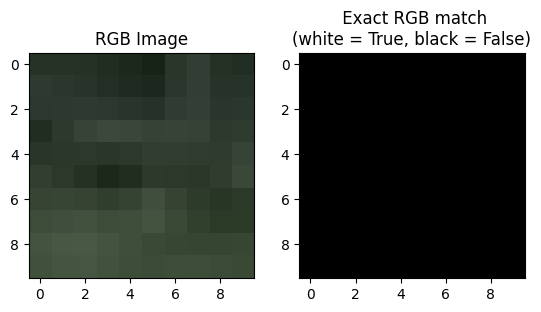

In [16]:
cond = (r == color[0]) & (g == color[1]) & (b == color[2])

cond_subset = cond[ystart:yend, xstart:xend]
rgb_subset = rgb[ystart:yend, xstart:xend, :]

ax = plt.subplot(1, 2, 1)
ax.imshow(rgb_subset)
ax.set_title("RGB Image")

ax = plt.subplot(1, 2, 2)
ax.imshow(cond_subset, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title(" Exact RGB match\n(white = True, black = False)")

Once you get a match, you might think that since the colors can vary in intensity 256 ways in each channel, this approach to finding "green" would be extremely tedious!

Well, we know from our exploration of conditional tests in earlier chapters that we can apply any test we want! This includes tests for *ranges* of values using `>`, `>=`, `<`, `<=`, `!=`, etc.

So, lets get a range of values for each channel in this subset:

In [17]:
for channel in range(3):

    max_ch = np.max(rgb_subset[:, :, channel])
    min_ch = np.min(rgb_subset[:, :, channel])

    print(f"For channel {channel} the range of values is {min_ch} to {max_ch}")

For channel 0 the range of values is 23 to 73
For channel 1 the range of values is 35 to 88
For channel 2 the range of values is 23 to 69




---


**Problem 1b.6**

Set the following values based on the results above:



---



In [18]:
ch0_min = 0
ch0_max = 1

ch1_min = 0
ch1_max = 1

ch2_min = 0
ch2_max = 1

We can update the tests to account for this range.

Do not change the code in the code cell immediately below this text cell:

In [19]:
r_cond = (r >= ch0_min) & (r <= ch0_max)
g_cond = (g >= ch1_min) & (g <= ch1_max)
b_cond = (b >= ch2_min) & (b <= ch2_max)

cond = r_cond & g_cond & b_cond

If you have all white pixels on the right, you have completed **Problem 1b.6**. If not, modify your min and max values above until you have all white pixels.

Do not change the code in the code cell immediately below this text cell:

Text(0.5, 1.0, ' Exact RGB match\n(white = True, black = False)')

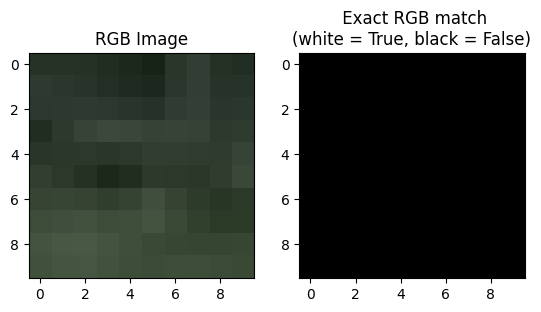

In [20]:
rgb_subset = rgb[ystart:yend, xstart:xend, :]
cond_subset = cond[ystart:yend, xstart:xend]

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(rgb_subset)
ax.set_title("RGB Image")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(cond_subset, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title(" Exact RGB match\n(white = True, black = False)")



---


**Problem 1b.7**

Answer in the markdown below: When you zoom out and examine the regional image, do the results make sense? How would you describe the results in a simple way to "Grandma Goody" who hasn't studied digital image processing since the 1980s.

ANSWER:



---



Text(0.5, 1.0, ' Exact RGB match\n(white = True, black = False)')

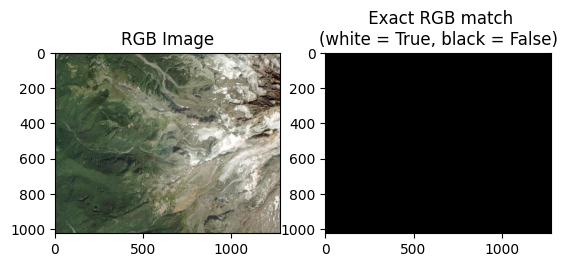

In [21]:
ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(cond, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title(" Exact RGB match\n(white = True, black = False)")

### Problem 2

Repeat the analysis above, except for snow-covered regions

---

Modify the code below to zoom in on a snow-covered region

---



Text(0.5, 1.0, 'RGB Image Zoom')

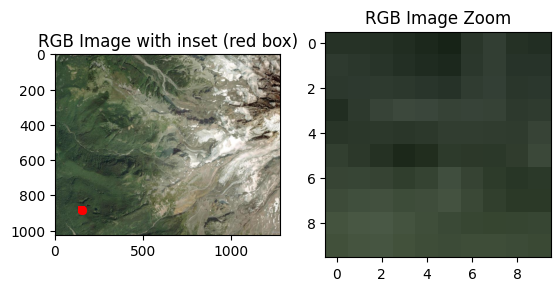

In [22]:
xstart = 150
xend = 160
ystart = 880
yend = 890

rgb_subset = rgb[ystart:yend, xstart:xend, :]
cond_subset = cond[ystart:yend, xstart:xend]

ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image with inset (red box)")
ax.plot([xstart, xstart, xend, xend, xstart],
         [ystart, yend, yend, ystart, ystart],
         "r-", lw=5)

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(rgb_subset)
ax.set_title("RGB Image Zoom")

---

Print the values in the subset region

---

In [23]:
rgb_subset

array([[[38, 50, 38],
        [38, 50, 38],
        [37, 49, 37],
        [33, 45, 33],
        [28, 40, 28],
        [23, 35, 23],
        [42, 54, 42],
        [50, 62, 51],
        [37, 49, 37],
        [34, 46, 35]],

       [[46, 58, 47],
        [43, 55, 44],
        [40, 52, 41],
        [35, 47, 36],
        [31, 43, 32],
        [28, 40, 29],
        [43, 55, 44],
        [50, 62, 51],
        [39, 51, 41],
        [39, 51, 41]],

       [[44, 56, 45],
        [45, 57, 47],
        [46, 58, 47],
        [44, 56, 45],
        [41, 53, 43],
        [38, 50, 40],
        [48, 60, 49],
        [51, 63, 53],
        [42, 54, 43],
        [43, 55, 45]],

       [[33, 45, 33],
        [45, 57, 45],
        [55, 67, 55],
        [60, 72, 60],
        [58, 70, 59],
        [54, 66, 54],
        [55, 67, 56],
        [54, 66, 54],
        [45, 57, 45],
        [47, 59, 47]],

       [[41, 53, 40],
        [43, 55, 42],
        [44, 56, 43],
        [42, 54, 41],
        [44, 56, 43],
        [49, 61, 48],
        [49, 61, 48],
        [48, 60, 47],
        [47, 59, 46],
        [55, 67, 54]],

       [[50, 63, 48],
        [44, 56, 42],
        [37, 49, 35],
        [28, 40, 26],
        [33, 45, 30],
        [45, 58, 43],
        [44, 56, 41],
        [43, 56, 41],
        [48, 60, 45],
        [59, 72, 57]],

       [[55, 68, 52],
        [55, 69, 53],
        [54, 67, 51],
        [48, 62, 45],
        [53, 67, 50],
        [64, 78, 62],
        [54, 67, 51],
        [45, 59, 42],
        [40, 54, 38],
        [43, 57, 41]],

       [[61, 75, 57],
        [64, 79, 61],
        [66, 80, 62],
        [61, 76, 57],
        [63, 77, 59],
        [68, 82, 64],
        [58, 72, 54],
        [49, 63, 45],
        [43, 57, 39],
        [43, 57, 39]],

       [[68, 83, 62],
        [72, 87, 67],
        [73, 88, 69],
        [68, 83, 63],
        [63, 78, 58],
        [58, 73, 54],
        [55, 70, 50],
        [54, 69, 48],
        [54, 69, 49],
        [55, 70, 51]],

       [[65, 80, 58],
        [69, 84, 63],
        [70, 85, 65],
        [66, 81, 59],
        [62, 77, 56],
        [60, 75, 55],
        [62, 77, 56],
        [62, 77, 56],
        [60, 75, 55],
        [58, 73, 52]]], dtype=uint8)



---

Set the range of values for the 3 channels and calculate the `cond` mask

---


In [24]:
ch0_min = 0
ch0_max = 1

ch1_min = 0
ch1_max = 1

ch2_min = 0
ch2_max = 1

r_cond = (r >= ch0_min) & (r <= ch0_max)
g_cond = (g >= ch1_min) & (g <= ch1_max)
b_cond = (b >= ch2_min) & (b <= ch2_max)

cond = r_cond & g_cond & b_cond

---

Plot the image and assess.

Answer in the markdown below: When you zoom out and examine the regional image, do the results make sense? How would you describe the results in a simple way to "Grandma Goody" who hasn't studied digital image processing since the 1980s.

ANSWER:

----

Text(0.5, 1.0, ' Exact RGB match\n(white = True, black = False)')

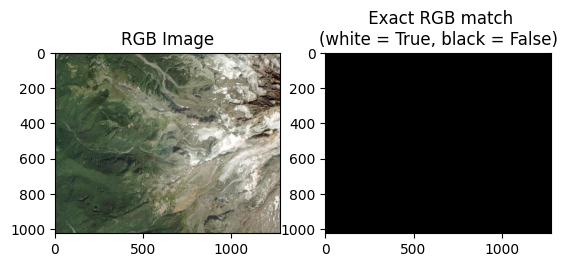

In [25]:
ax = plt.subplot(1, 2, 1)
mmp = ax.imshow(rgb)
ax.set_title("RGB Image")

ax = plt.subplot(1, 2, 2)
mmp = ax.imshow(cond, cmap='Greys_r', vmin=0, vmax=1)
ax.set_title(" Exact RGB match\n(white = True, black = False)")